In [ ]:

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_circles
import pandas as pd
import zipfile
import os
import pathlib
import numpy as np

In [ ]:
from google.colab import files
uploaded = files.upload("C:\\Users\\vicky\\Downloads\\Dataset.csv")


Saving Dataset .csv to C:\Users\vicky\Downloads\Dataset.csv/Dataset  (4).csv


In [149]:
import io

# Assuming only one file was uploaded, get its content
file_content = next(iter(uploaded.values()))

p = pd.read_csv(io.BytesIO(file_content))
p

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,5915730,Naml۱ Gurme,208,��stanbul,"Kemanke�� Karamustafa Pa��a Mahallesi, R۱ht۱m ...",Karak�_y,"Karak�_y, ��stanbul",28.977392,41.022793,Turkish,...,Turkish Lira(TL),No,No,No,No,3,4.1,Green,Very Good,788
9547,5908749,Ceviz A��ac۱,208,��stanbul,"Ko��uyolu Mahallesi, Muhittin ��st�_nda�� Cadd...",Ko��uyolu,"Ko��uyolu, ��stanbul",29.041297,41.009847,"World Cuisine, Patisserie, Cafe",...,Turkish Lira(TL),No,No,No,No,3,4.2,Green,Very Good,1034
9548,5915807,Huqqa,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.034640,41.055817,"Italian, World Cuisine",...,Turkish Lira(TL),No,No,No,No,4,3.7,Yellow,Good,661
9549,5916112,A���k Kahve,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.036019,41.057979,Restaurant Cafe,...,Turkish Lira(TL),No,No,No,No,4,4.0,Green,Very Good,901


In [ ]:
from sklearn.model_selection import train_test_split
len(p)
x_train,y_train=train_test_split(p, test_size=0.2, random_state=4)
len(x_train)

7640

In [ ]:
p.isnull().sum()


,0
Restaurant ID,0
Country Code,0
Longitude,0
Latitude,0
Average Cost for two,0
...,...
Rating color_Green,0
Rating color_Orange,0
Rating color_Red,0
Rating color_White,0


In [ ]:
p['Cuisines']


,Cuisines
0,"French, Japanese, Desserts"
1,Japanese
2,"Seafood, Asian, Filipino, Indian"
3,"Japanese, Sushi"
4,"Japanese, Korean"
...,...
9546,Turkish
9547,"World Cuisine, Patisserie, Cafe"
9548,"Italian, World Cuisine"
9549,Restaurant Cafe


In [ ]:
from sklearn.preprocessing import StandardScaler

p['Cuisines'].fillna(p['Cuisines'].mode()[0], inplace=True)


In [ ]:
p

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,5915730,Naml۱ Gurme,208,��stanbul,"Kemanke�� Karamustafa Pa��a Mahallesi, R۱ht۱m ...",Karak�_y,"Karak�_y, ��stanbul",28.977392,41.022793,Turkish,...,Turkish Lira(TL),No,No,No,No,3,4.1,Green,Very Good,788
9547,5908749,Ceviz A��ac۱,208,��stanbul,"Ko��uyolu Mahallesi, Muhittin ��st�_nda�� Cadd...",Ko��uyolu,"Ko��uyolu, ��stanbul",29.041297,41.009847,"World Cuisine, Patisserie, Cafe",...,Turkish Lira(TL),No,No,No,No,3,4.2,Green,Very Good,1034
9548,5915807,Huqqa,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.034640,41.055817,"Italian, World Cuisine",...,Turkish Lira(TL),No,No,No,No,4,3.7,Yellow,Good,661
9549,5916112,A���k Kahve,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.036019,41.057979,Restaurant Cafe,...,Turkish Lira(TL),No,No,No,No,4,4.0,Green,Very Good,901


In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

le = LabelEncoder()

columns_to_encode = ['Has Online delivery', 'Has Table booking', 'Is delivering now', 'Switch to order menu']

for col in columns_to_encode:
    p[col] = le.fit_transform(p[col])

In [ ]:
p.drop(
    ['Restaurant Name', 'Address', 'Locality', 'Locality Verbose'],
    axis=1,
    inplace=True
)

In [ ]:
p = pd.get_dummies(
    p,
    columns=['City', 'Cuisines', 'Currency', 'Rating color'],
    drop_first=True
)

rating_map = {
    'Poor': 1,
    'Average': 2,
    'Good': 3,
    'Very Good': 4,
    'Excellent': 5
}
p['Rating text'] = p['Rating text'].map(rating_map)
p

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,...,Currency_Pounds(��),Currency_Qatari Rial(QR),Currency_Rand(R),Currency_Sri Lankan Rupee(LKR),Currency_Turkish Lira(TL),Rating color_Green,Rating color_Orange,Rating color_Red,Rating color_White,Rating color_Yellow
0,6317637,162,121.027535,14.565443,1100,1,0,0,0,3,...,False,False,False,False,False,False,False,False,False,False
1,6304287,162,121.014101,14.553708,1200,1,0,0,0,3,...,False,False,False,False,False,False,False,False,False,False
2,6300002,162,121.056831,14.581404,4000,1,0,0,0,4,...,False,False,False,False,False,True,False,False,False,False
3,6318506,162,121.056475,14.585318,1500,0,0,0,0,4,...,False,False,False,False,False,False,False,False,False,False
4,6314302,162,121.057508,14.584450,1500,1,0,0,0,4,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,5915730,208,28.977392,41.022793,80,0,0,0,0,3,...,False,False,False,False,True,True,False,False,False,False
9547,5908749,208,29.041297,41.009847,105,0,0,0,0,3,...,False,False,False,False,True,True,False,False,False,False
9548,5915807,208,29.034640,41.055817,170,0,0,0,0,4,...,False,False,False,False,True,False,False,False,False,True
9549,5916112,208,29.036019,41.057979,120,0,0,0,0,4,...,False,False,False,False,True,True,False,False,False,False


In [ ]:
x = p.drop('Aggregate rating', axis=1)
y = p['Aggregate rating']

In [ ]:
X_train,X_test,Y_train,Y_test=train_test_split(x,y,train_size=0.8,test_size=0.2,random_state=20)
len(X_train)

7640

In [ ]:
len(X_test)
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, Y_train)

LinearRegression()

In [ ]:
# Decision Tree Regressor
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, Y_train)

DecisionTreeRegressor(random_state=42)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
lr_pred = lr.predict(X_test)
print("Linear Regression")
print("MSE:", mean_squared_error(Y_test, lr_pred))
print("R2 Score:", r2_score(Y_test, lr_pred))
print("-" * 40)

Linear Regression
MSE: 0.034114105185800526
R2 Score: 0.9846969161630633
----------------------------------------


In [ ]:
dt_pred = dt.predict(X_test)
print("Decision Tree Regression")
print("MSE:", mean_squared_error(Y_test, dt_pred))
print("R2 Score:", r2_score(Y_test, dt_pred))

Decision Tree Regression
MSE: 0.04874934589220303
R2 Score: 0.9781317632949457


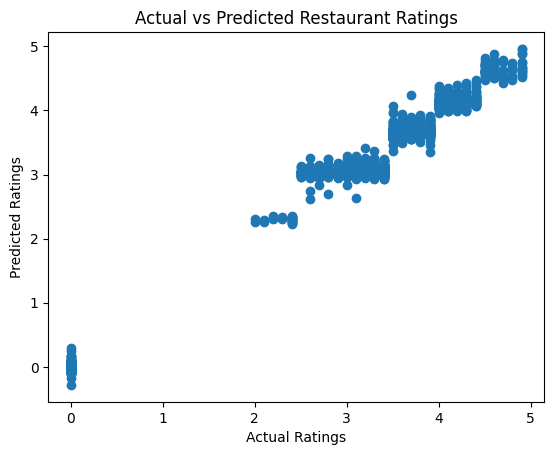

In [ ]:
import matplotlib.pyplot as plt



plt.figure()
plt.scatter(Y_test, lr_pred)
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Restaurant Ratings")
plt.show()
